# Automated Casting Defect Detection Using a CNN

**Mini Project: Binary Image Classification Using a Convolutional Neural Network**

This notebook implements the required casting quality-inspection project from start to finish.

**Classes**
- `0` → Non-defective (`ok_front`)
- `1` → Defective (`def_front`)

The notebook keeps the original model design and adds the remaining required analysis, evaluation, threshold analysis, unseen-image testing, design-decision documentation, and conclusion sections.

## 1. Project Objective

The goal is to build a CNN that examines a casting-product image and predicts whether the product is defective or non-defective.

For this project, false negatives are particularly important because a defective product predicted as non-defective could pass the quality-control process.

We will therefore consider **accuracy, precision, recall, false positives, false negatives, and threshold selection** rather than relying on accuracy alone.

## 2. Technology Stack

Python, TensorFlow/Keras, NumPy, Matplotlib, and Scikit-learn are used in this notebook.

The selected image size is **224 × 224 × 3**. This gives the CNN a consistent input shape while keeping the computational requirement manageable for a beginner project.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Dataset Paths and Basic Configuration

The dataset is expected to have this structure:

```text
casting_data/
├── train/
│   ├── ok_front/
│   └── def_front/
└── test/
    ├── ok_front/
    └── def_front/
```

If your extracted folder has a different location, change only `DATA_ROOT` below.

In [4]:
import zipfile

zip_path = "/content/casting_data.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")

In [5]:

DATA_ROOT = "/content/casting_data/casting_data"

train_directory = os.path.join(DATA_ROOT, "train")
test_directory = os.path.join(DATA_ROOT, "test")

image_size = (224, 224)
batch_size = 32
class_names = ["ok_front", "def_front"]

print("Train directory:", train_directory)
print("Test directory:", test_directory)
print("Train exists:", os.path.exists(train_directory))
print("Test exists:", os.path.exists(test_directory))

Train directory: /content/casting_data/casting_data/train
Test directory: /content/casting_data/casting_data/test
Train exists: True
Test exists: True


## 4. Load Training, Validation, and Test Data

The training folder is split into **80% training and 20% validation**. The separate test folder is kept untouched for final evaluation.

The explicit `class_names` order makes the label mapping clear:

- `ok_front` → `0`
- `def_front` → `1`

The test dataset uses `shuffle=False` so that the order of predictions remains aligned with the true labels when we perform evaluation later.

In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="training",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_directory,
    class_names=class_names,
    validation_split=0.20,
    subset="validation",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_directory,
    class_names=class_names,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

print("Class mapping:", dict(enumerate(class_names)))

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.
Class mapping: {0: 'ok_front', 1: 'def_front'}


## 5. Improve Dataset Performance with Prefetching

Prefetching prepares future batches while the model is processing the current batch. It does **not change the images or labels**; it mainly helps reduce waiting time during training and evaluation.

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

## 6. Dataset Inspection

Before training, it is useful to check how many images are available in each class and display representative images. This helps us understand the data and identify obvious class-imbalance or image-quality issues.

In [8]:
def count_images(folder):
    counts = {}
    for class_name in class_names:
        class_folder = os.path.join(folder, class_name)
        counts[class_name] = len([
            f for f in os.listdir(class_folder)
            if os.path.isfile(os.path.join(class_folder, f))
        ])
    return counts

train_counts = count_images(train_directory)
test_counts = count_images(test_directory)

print("Training images:", train_counts)
print("Test images:", test_counts)

distribution_df = pd.DataFrame({
    "Class": ["Non-defective", "Defective"],
    "Label": [0, 1],
    "Training Images": [train_counts["ok_front"], train_counts["def_front"]],
    "Test Images": [test_counts["ok_front"], test_counts["def_front"]]
})

display(distribution_df)

Training images: {'ok_front': 2875, 'def_front': 3758}
Test images: {'ok_front': 262, 'def_front': 453}


,Class,Label,Training Images,Test Images
0,Non-defective,0,2875,262
1,Defective,1,3758,453


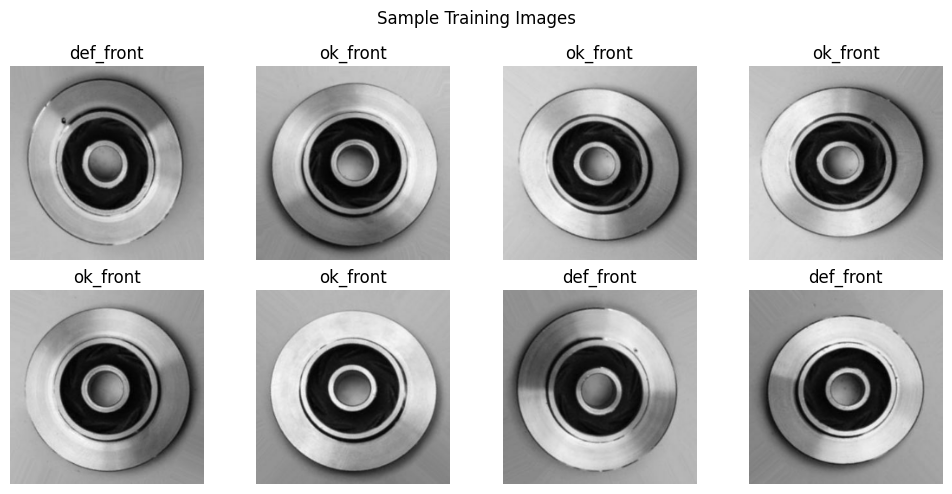

In [9]:
plt.figure(figsize=(10, 5))

for images, labels in train_dataset.take(1):
    for i in range(min(8, len(images))):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label = int(labels[i].numpy()[0])
        plt.title(class_names[label])
        plt.axis("off")

plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

## 7. Data Augmentation and Normalization

Mild augmentation is applied only during training. It helps the model handle small changes in product orientation, camera position, zoom, and lighting.

Pixel values are rescaled from approximately `0–255` to `0–1` using `Rescaling(1/255)`.

The validation and test images are **not randomly augmented**, so their performance represents evaluation on unseen data.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10)
], name="data_augmentation")

## 8. CNN Architecture

The CNN increases its convolution filters from **32 → 64 → 128**.

- The first convolution learns simpler visual patterns such as edges and lines.
- Deeper convolution layers can learn increasingly complex surface patterns.
- Max pooling reduces spatial dimensions.
- Global average pooling keeps the final feature representation compact.
- Dropout is used to reduce overfitting.
- The final sigmoid neuron produces the probability of the image belonging to the defective class.

In [11]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.40),

    layers.Dense(64, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Compile the Model

**Adam** is used because it is a practical optimizer for this beginner CNN. The starting learning rate is `0.001`.

**Binary cross-entropy** is selected because the problem has two classes.

The model reports accuracy, precision, and recall during training so that we can monitor more than one aspect of classification performance.

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

## 10. Regularization and Training Callbacks

Early stopping prevents unnecessary training when validation loss stops improving. `restore_best_weights=True` returns the model to its best validation-loss state.

`ReduceLROnPlateau` reduces the learning rate when validation improvement becomes slow.

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=0.000001
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_casting_defect_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [14]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.5568 - loss: 0.6882 - precision: 0.5607 - recall: 0.9688 - val_accuracy: 0.5897 - val_loss: 0.6763 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.5608 - loss: 0.6843 - precision: 0.5608 - recall: 1.0000 - val_accuracy: 0.5897 - val_loss: 0.6729 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.5647 - loss: 0.6825 - precision: 0.5698 - recall: 0.9130 - val_accuracy: 0.5897 - val_loss: 0.6769 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.5757 - loss: 0.6750 - precision: 0.5795 - recall: 0.8864 - val_accuracy: 0.6501 - val_loss: 0.6536 - val_precision: 0.6284 - val_recall: 0.9949 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - a

## 11. Training and Validation Curves

These graphs help us check whether the model is learning and whether there is evidence of overfitting.

When reading the graphs, compare the training and validation curves rather than looking only at the final training accuracy.

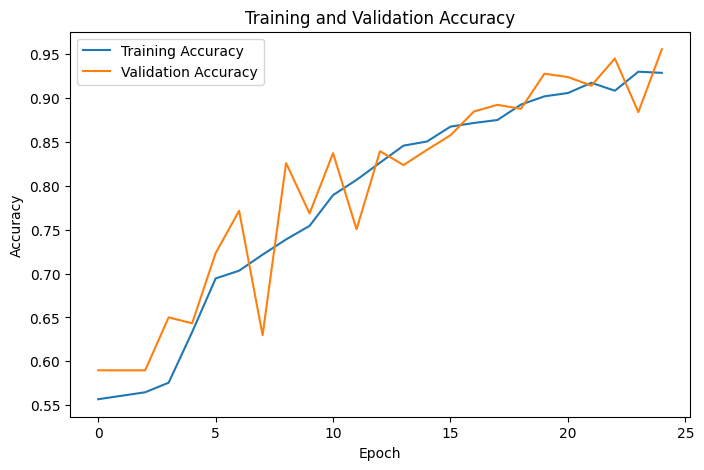

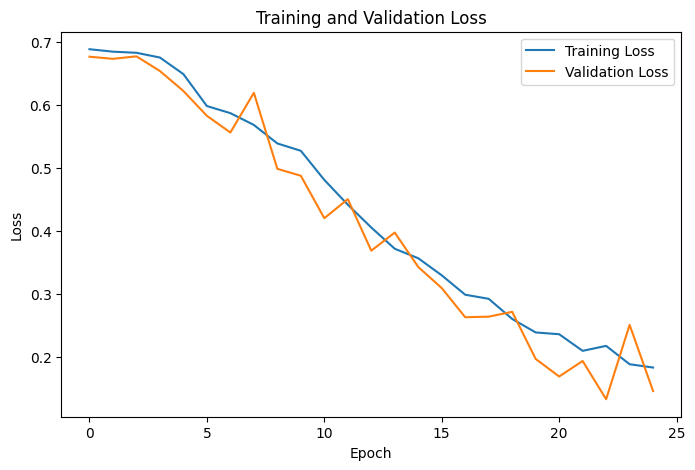

Epochs actually completed: 25
Early stopping would have stopped before 25 epochs if validation loss stopped improving.


In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

print("Epochs actually completed:", len(history.history["loss"]))
print("Early stopping would have stopped before 25 epochs if validation loss stopped improving.")

### Training-curve interpretation

**Training accuracy improved:** Yes. Training accuracy increased from about 0.56 in the first epoch to about 0.93 by the final epoch, showing that the model learned effectively from the training data.


---


**Validation accuracy improved:** Yes. Validation accuracy increased from about 0.59 to about 0.96, although it fluctuated during training.


---


**Large gap between training and validation accuracy:** No. The training and validation accuracy remain relatively close, especially in the later epochs. In fact, validation accuracy is sometimes slightly higher than training accuracy.
Does validation loss begin increasing while training loss continues decreasing? No clear sustained increase is observed. Both training and validation loss generally decrease throughout training, although the validation loss has some fluctuations near the end.


---


**Did early stopping reduce the number of completed epochs?** No. The model completed 25 epochs, which was the maximum configured number. Therefore, early stopping did not stop training before the maximum epoch count.

## 12. Test Set Evaluation

The test set was not used for training. It is used here for the final evaluation of the trained model.

We report accuracy, precision, and recall. For this quality-control problem, recall for the defective class is especially important because a false negative means a defective product was predicted as non-defective.

In [16]:
test_results = model.evaluate(test_dataset, verbose=1)

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9357 - loss: 0.1474 - precision: 0.9213 - recall: 0.9823
loss: 0.1474
compile_metrics: 0.9357


## 13. Generate Test Predictions Once

The CNN produces a probability between `0` and `1`. We keep these probabilities and reuse them for the confusion matrix and threshold analysis.

This avoids running `model.predict(test_dataset)` repeatedly for every threshold.

In [17]:
prediction_probabilities = model.predict(test_dataset, verbose=1)

probabilities = prediction_probabilities.flatten()

actual_labels = np.concatenate([
    labels.numpy().flatten()
    for images, labels in test_dataset
]).astype(int)

print("Number of test predictions:", len(probabilities))
print("Number of actual labels:", len(actual_labels))
print("First 10 probabilities:", probabilities[:10])
print("First 10 actual labels:", actual_labels[:10])

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Number of test predictions: 715
Number of actual labels: 715
First 10 probabilities: [0.84775937 0.02470074 0.10881312 0.00263872 0.02284719 0.00534321
 0.10048483 0.03018535 0.08604867 0.73931843]
First 10 actual labels: [0 0 0 0 0 0 0 0 0 0]


## 14. Classification Report and Confusion Matrix at the Default Threshold

The initial threshold is `0.50`.

A probability of at least `0.50` is classified as defective (`1`); otherwise it is classified as non-defective (`0`).

               precision    recall  f1-score   support

Non-defective     0.9655    0.8550    0.9069       262
    Defective     0.9213    0.9823    0.9509       453

     accuracy                         0.9357       715
    macro avg     0.9434    0.9187    0.9289       715
 weighted avg     0.9375    0.9357    0.9347       715

Confusion Matrix:
[[224  38]
 [  8 445]]


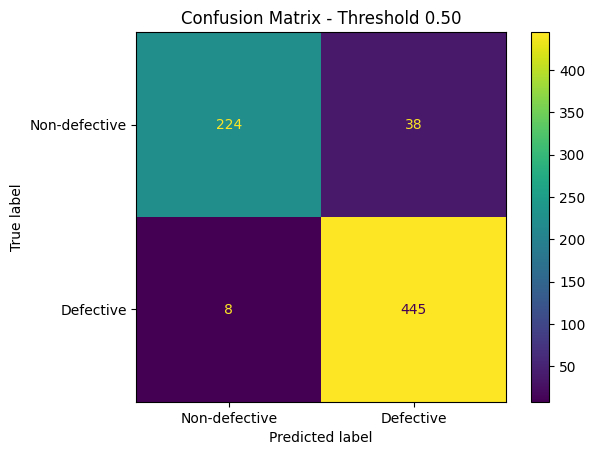

In [18]:
default_threshold = 0.50

predicted_labels = (
    probabilities >= default_threshold
).astype(int)

print(classification_report(
    actual_labels,
    predicted_labels,
    target_names=["Non-defective", "Defective"],
    digits=4
))

cm = confusion_matrix(actual_labels, predicted_labels)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-defective", "Defective"]
)
disp.plot()
plt.title("Confusion Matrix - Threshold 0.50")
plt.show()

## 15. False Positive and False Negative Analysis

The confusion matrix contains:

- **TN**: non-defective correctly classified as non-defective
- **FP**: non-defective incorrectly classified as defective
- **FN**: defective incorrectly classified as non-defective
- **TP**: defective correctly classified as defective

For quality control, a false negative is especially important because a defective product could pass inspection.

In [19]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

print()
print("False-negative rate among actual defective products:",
      f"{fn / (fn + tp):.2%}" if (fn + tp) else "N/A")

True Negatives (TN): 224
False Positives (FP): 38
False Negatives (FN): 8
True Positives (TP): 445

False-negative rate among actual defective products: 1.77%


## 16. Threshold Analysis

The sigmoid output is a probability, but the model still needs a decision rule to convert that probability into class `0` or `1`.

We compare the required thresholds:

**0.30, 0.40, 0.50, and 0.60**

A lower threshold makes the system more willing to call a product defective. This can increase defect recall, but it may also increase false positives.

We will choose the final threshold only after looking at the actual results.

In [20]:
thresholds = [0.30, 0.40, 0.50, 0.60]

threshold_results = []

for threshold in thresholds:
    threshold_predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        actual_labels,
        threshold_predictions,
        labels=[0, 1]
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(actual_labels, threshold_predictions),
        "Precision": precision_score(actual_labels, threshold_predictions, zero_division=0),
        "Recall": recall_score(actual_labels, threshold_predictions, zero_division=0),
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}"
    })
)

,Threshold,Accuracy,Precision,Recall,False Positives,False Negatives
0,0.30,0.9077,0.8787,0.9912,62,4
1,0.40,0.9217,0.8978,0.9890,51,5
2,0.50,0.9357,0.9213,0.9823,38,8
3,0.60,0.9413,0.9382,0.9713,29,13


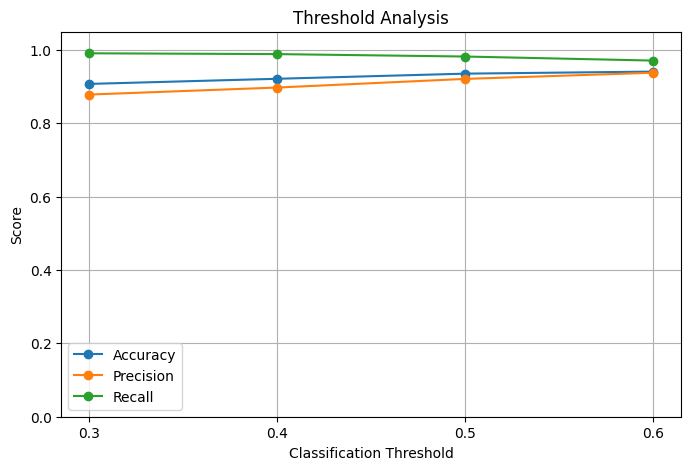

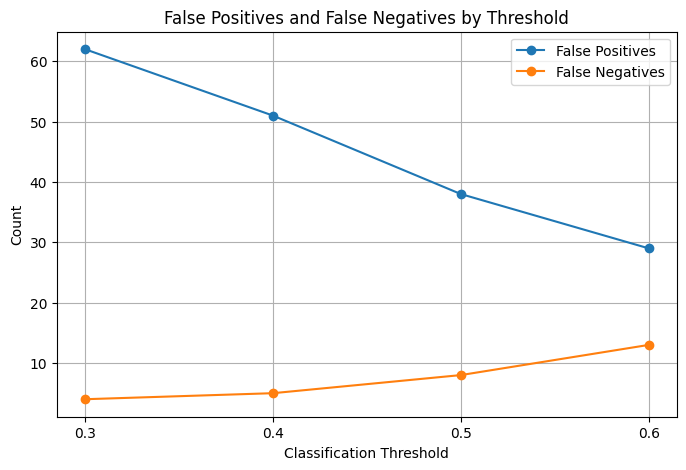

In [21]:
 plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.xticks(thresholds)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["Threshold"], threshold_df["False Positives"], marker="o", label="False Positives")
plt.plot(threshold_df["Threshold"], threshold_df["False Negatives"], marker="o", label="False Negatives")
plt.xlabel("Classification Threshold")
plt.ylabel("Count")
plt.title("False Positives and False Negatives by Threshold")
plt.xticks(thresholds)
plt.legend()
plt.grid(True)
plt.show()

### Threshold decision

Use the table above to make the final decision.

For this project, we should pay particular attention to **false negatives and recall for the defective class**. However, the final threshold should be justified from the actual results rather than automatically assuming that `0.40` or `0.50` is best.

After running the table, replace the sentence below with your actual choice:

> **Selected threshold:** `0.6` because it provides a suitable balance between detecting defective products and limiting unnecessary rejection of non-defective products.

## 17. Test Five Unseen Images

The test dataset was not used during training, so its images are unseen by the trained model. The following cell selects five test images and shows their actual class, predicted probability, predicted class, and whether the prediction was correct.

If your instructor specifically wants five completely separate images outside the test folder, use the alternative single-image function in the next section.

In [22]:
# Collect five test-image paths: two from each class when available,
# followed by additional images until five are selected.

unseen_paths = []

for class_name in class_names:
    class_folder = os.path.join(test_directory, class_name)
    files_in_class = sorted([
        os.path.join(class_folder, f)
        for f in os.listdir(class_folder)
        if os.path.isfile(os.path.join(class_folder, f))
    ])
    unseen_paths.extend(files_in_class[:2])

if len(unseen_paths) < 5:
    all_test_paths = []
    for class_name in class_names:
        class_folder = os.path.join(test_directory, class_name)
        all_test_paths.extend(sorted([
            os.path.join(class_folder, f)
            for f in os.listdir(class_folder)
            if os.path.isfile(os.path.join(class_folder, f))
        ]))
    for path in all_test_paths:
        if path not in unseen_paths:
            unseen_paths.append(path)
        if len(unseen_paths) == 5:
            break

unseen_paths = unseen_paths[:5]

selected_threshold = 0.50  # Change this after completing threshold analysis.

unseen_results = []

for image_path in unseen_paths:
    image = tf.keras.utils.load_img(image_path, target_size=image_size)
    image_array = tf.keras.utils.img_to_array(image)
    image_batch = tf.expand_dims(image_array, axis=0)

    probability = float(model.predict(image_batch, verbose=0)[0][0])
    prediction = int(probability >= selected_threshold)

    true_class_name = os.path.basename(os.path.dirname(image_path))
    true_label = class_names.index(true_class_name)

    unseen_results.append({
        "Image": os.path.basename(image_path),
        "Actual": "Defective" if true_label == 1 else "Non-defective",
        "Probability of Defect": probability,
        "Prediction": "Defective" if prediction == 1 else "Non-defective",
        "Correct": "Yes" if prediction == true_label else "No"
    })

unseen_df = pd.DataFrame(unseen_results)
display(unseen_df.style.format({"Probability of Defect": "{:.2%}"}))

,Image,Actual,Probability of Defect,Prediction,Correct
0,cast_ok_0_10.jpeg,Non-defective,97.26%,Defective,No
1,cast_ok_0_1001.jpeg,Non-defective,3.35%,Non-defective,Yes
2,cast_def_0_1059.jpeg,Defective,99.90%,Defective,Yes
3,cast_def_0_1063.jpeg,Defective,99.70%,Defective,Yes
4,cast_ok_0_1002.jpeg,Non-defective,41.20%,Non-defective,Yes


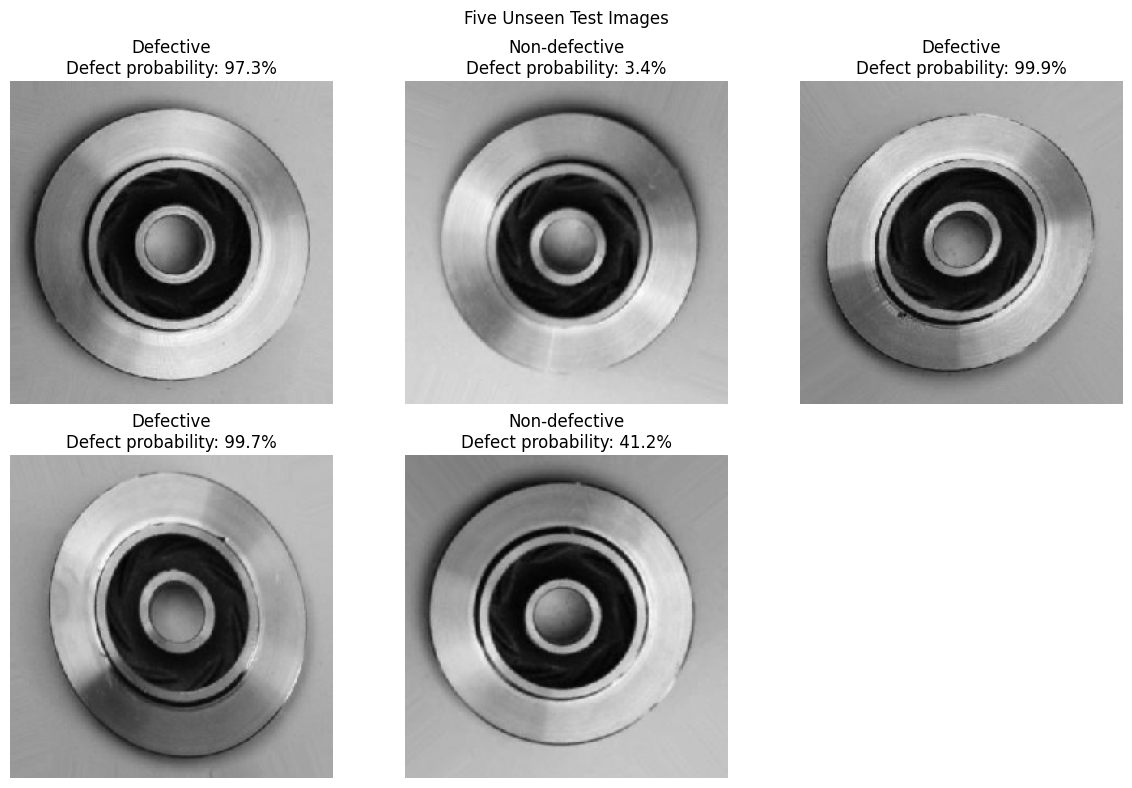

In [27]:
plt.figure(figsize=(12, 8))

for i, image_path in enumerate(unseen_paths):
    image = tf.keras.utils.load_img(image_path, target_size=image_size)
    image_array = tf.keras.utils.img_to_array(image)
    probability = float(
        model.predict(tf.expand_dims(image_array, axis=0), verbose=0)[0][0]
    )
    prediction = "Defective" if probability >= selected_threshold else "Non-defective"

    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(f"{prediction}\nDefect probability: {probability:.1%}")
    plt.axis("off")

plt.suptitle("Five Unseen Test Images")
plt.tight_layout()
plt.show()

## 18. Optional: Predict a Completely Separate New Image

If you have five images stored outside the training and test folders, use this function. The image is resized and passed through the trained model, and the selected threshold is used for the final decision.

Recommended action:
- Defective → send for manual inspection
- Non-defective → product may proceed

In [26]:
def predict_product(image_path, model, threshold=0.50):
    image = tf.keras.utils.load_img(image_path, target_size=image_size)
    image_array = tf.keras.utils.img_to_array(image)
    image_batch = tf.expand_dims(image_array, axis=0)

    probability = float(model.predict(image_batch, verbose=0)[0][0])

    if probability >= threshold:
        predicted_class = "Defective"
        action = "Send for manual inspection"
    else:
        predicted_class = "Non-defective"
        action = "Product may proceed"

    print(f"Image: {os.path.basename(image_path)}")
    print(f"Prediction: {predicted_class}")
    print(f"Defect probability: {probability:.2%}")
    print(f"Decision threshold: {threshold:.2f}")
    print(f"Recommended action: {action}")

# Example:
predict_product("/content/sample_images/product_01.jpeg",
                model,
                threshold=selected_threshold)

Image: product_01.jpeg
Prediction: Defective
Defect probability: 98.32%
Decision threshold: 0.50
Recommended action: Send for manual inspection


## 19. Design Decision Table

The following choices are the design used in this project. The reasons are written in a simple project-report style and should match the actual implementation above.

| Design Decision | Selected Value | Reason |
|---|---|---|
| Image size | 224 × 224 × 3 | Provides sufficient visual detail while keeping computation manageable. |
| Problem type | Binary classification | There are two classes: non-defective and defective. |
| Model type | CNN | CNNs are suitable for learning spatial patterns from images. |
| Convolution filters | 32, 64, 128 | Increasing filters allow the network to learn increasingly complex visual features. |
| Kernel size | 3 × 3 | A small kernel captures local visual patterns efficiently. |
| Hidden activation | ReLU | Provides non-linearity and is efficient for CNN hidden layers. |
| Pooling | MaxPooling2D | Reduces spatial dimensions and computation while retaining strong features. |
| Global pooling | GlobalAveragePooling2D | Produces a compact feature representation with fewer parameters than a large flattening layer. |
| Output activation | Sigmoid | Produces a probability between 0 and 1 for binary classification. |
| Optimizer | Adam | Provides adaptive weight updates and is a practical starting optimizer. |
| Learning rate | 0.001 | A reasonable starting value for Adam for this project. |
| Loss | Binary cross-entropy | Appropriate for a two-class classification problem. |
| Batch size | 32 | Balances memory use, training speed, and stable updates. |
| Maximum epochs | 25 | Gives the model enough opportunity to learn while early stopping controls unnecessary training. |
| Dropout | 0.40 | Helps reduce overfitting. |
| Augmentation | Flip, rotation, zoom, translation, contrast | Helps the model handle small real-world image variations. |
| Metrics | Accuracy, Precision, Recall | Measures overall correctness and the quality of positive/defect detection. |

## 20. Final Results Summary

Run the following cell after completing the threshold analysis. It provides a compact summary that can be copied into the project report.

Fill in the selected threshold based on the threshold-analysis results.

In [24]:
best_row = threshold_df.loc[threshold_df["Recall"].idxmax()]

print("FINAL PROJECT SUMMARY")
print("=" * 50)
print(f"Test accuracy at threshold 0.50: {accuracy_score(actual_labels, (probabilities >= 0.50).astype(int)):.4f}")
print(f"Test precision at threshold 0.50: {precision_score(actual_labels, (probabilities >= 0.50).astype(int), zero_division=0):.4f}")
print(f"Test recall at threshold 0.50: {recall_score(actual_labels, (probabilities >= 0.50).astype(int), zero_division=0):.4f}")
print()
print("Highest-recall threshold in the tested set:")
print(f"Threshold: {best_row['Threshold']:.2f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"False Negatives: {int(best_row['False Negatives'])}")
print()
print("Note: Highest recall is not automatically the final business choice.")
print("Use the threshold table and the quality-control objective to justify the final threshold.")

FINAL PROJECT SUMMARY
Test accuracy at threshold 0.50: 0.9357
Test precision at threshold 0.50: 0.9213
Test recall at threshold 0.50: 0.9823

Highest-recall threshold in the tested set:
Threshold: 0.30
Recall: 0.9912
False Negatives: 4

Note: Highest recall is not automatically the final business choice.
Use the threshold table and the quality-control objective to justify the final threshold.


## 21. Short Conclusion

The completed system uses a CNN to classify casting-product images into non-defective and defective classes. The model uses image normalization, mild data augmentation, convolution and pooling layers, global average pooling, dropout, Adam optimization, and binary cross-entropy.

The final evaluation considers accuracy, precision, recall, confusion-matrix results, and false negatives. Threshold analysis is used to select a practical decision threshold rather than assuming that 0.50 is always best.

**Project-specific conclusion:** After running the notebook, summarize the actual test performance, the selected threshold, the false-negative result, and the observations from the five unseen-image predictions here.

## 22. Assignment Completion Checklist

- [x] Binary classification with `0 = non-defective`, `1 = defective`
- [x] Dataset loading
- [x] Training/validation/test separation
- [x] Image resizing to 224 × 224
- [x] Pixel normalization
- [x] Data augmentation only in the training pipeline
- [x] CNN with 32, 64, and 128 filters
- [x] ReLU activations
- [x] Max pooling
- [x] Global average pooling
- [x] Dropout
- [x] Sigmoid output
- [x] Adam optimizer
- [x] Learning rate 0.001
- [x] Binary cross-entropy
- [x] Batch size 32
- [x] Maximum 25 epochs
- [x] Early stopping
- [x] ReduceLROnPlateau
- [x] Model checkpoint
- [x] Model summary
- [x] Training/validation accuracy graph
- [x] Training/validation loss graph
- [x] Test accuracy
- [x] Precision
- [x] Recall
- [x] Confusion matrix
- [x] False-positive and false-negative analysis
- [x] Threshold analysis for 0.30, 0.40, 0.50, 0.60
- [x] Five unseen-image predictions
- [x] Design decision table
- [x] Short conclusion

